In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import animation, rc
rc('animation', html='html5')

/Users/shrutisingh/Desktop/PhD classes/Fall 23/Artificial Intelligence/Assignment/HW2_Shruti/gridworld_part2.py:121: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  self.ax.plot(self.AGENTS_X, self.AGENTS_Y, 'ok', markersize=10, color = 'green')


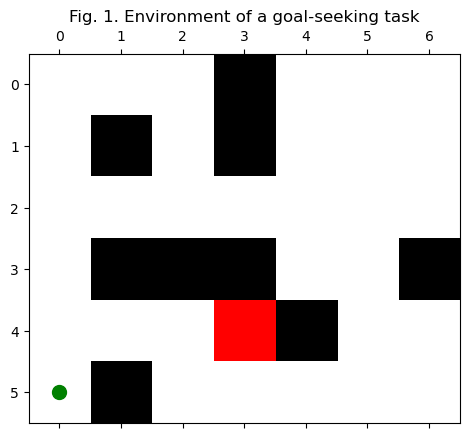

In [2]:
from gridworld_part2 import Environment
env =  Environment()
s = env.reset()

Define the Map

In [3]:
map = [
    ['.', '.', '.', '#', '.', '.', '.'],
    ['.', '#', '.', '#', '.', '.', '.'],
    ['.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '.', '.', '#'],
    ['.', '.', '.', 'G', '#', '.', '.'],
    ['S', '#', '.', '.', '.', '.', '.'],
]

In [4]:
start = (env.AGENTS_Y, env.AGENTS_X)
goal = env.TARGETS_YX[0]
print(start, goal)

(5, 0) (4, 3)


DFS Agent

In [5]:
# Define an agent
from myAgent import DFSAgent
agent_dfs = DFSAgent()
trajectory_dfs = []

In [6]:
"""
Trajectory through path from DFS: Uncomment to see the same path
"""
# isFound, path, selected_actions = agent_dfs.dfs_search(map, start, goal)
# trajectory_dfs = path
# print(trajectory_dfs)
# print('Actions', selected_actions)

'\nTrajectory through path from DFS: Uncomment to see the same path\n'

In [7]:
"""
Trajectory following the actions from DFS
Path obtained from Step function is the same as the 'path' from DFS
"""
isFound, path, selected_actions = agent_dfs.dfs_search(map, start, goal)
for action in selected_actions:
    s, reward, terminal, agentX, agentY = env.step(action)
    trajectory_dfs.append((agentX, agentY))
    if terminal:
        break
trajectory_dfs = [(start[1],start[0])] + trajectory_dfs
print(trajectory_dfs)


Depth First Search (DFS)
[(0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 1), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (5, 2), (5, 3), (5, 4), (6, 4), (6, 5), (5, 5), (4, 5), (3, 5), (3, 4)]


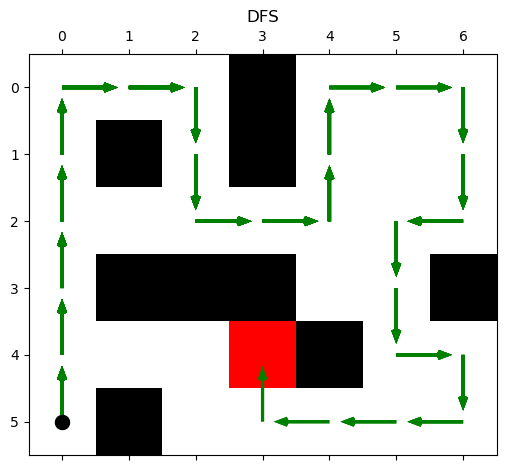

In [8]:
fig, ax = env.showGrid()
ax.plot(trajectory_dfs[0][0], trajectory_dfs[0][1], 'ok', markersize=10) #draw the spawn location of the agent
xs, ys = zip(*trajectory_dfs)
ax.set_title(f"DFS")
fig.tight_layout()
def update_quiver(i):
    # Switch the y and x variables to unpack the coordinates correctly if using the trajectory from Path
    x = np.array(xs)[:i] 
    y = np.array(ys)[:i]
    ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1],
    scale_units='xy', angles='xy', scale=1.2, color='g', width=0.007, headwidth=3., headlength=4.)
anim = animation.FuncAnimation(fig, update_quiver, frames=len(trajectory_dfs)+1, interval=500, blit=False, repeat=True)
anim.save('plot_grid.gif', writer=animation.PillowWriter(fps=60))
plt.show()

BFS Agent

In [9]:
env =  Environment()
s = env.reset()

In [10]:
# Define an agent
from myAgent import BFSAgent
agent_bfs = BFSAgent()
trajectory_bfs = []

In [11]:
"""
Trajectory through path from BFS: Uncomment to see the same path
"""
# isFound, path, selected_actions = agent_bfs.bfs_search(map, start, goal)
# trajectory_bfs.insert(0, start)
# trajectory_bfs[1:1] = path
# print(trajectory_bfs)

'\nTrajectory through path from BFS: Uncomment to see the same path\n'

In [12]:
"""
Trajectory following the actions from BFS
Path obtained from Step function is the same as the 'path' from BFS
"""
isFound, path, selected_actions = agent_bfs.bfs_search(map, start, goal)

for action in selected_actions:
    s, reward, terminal, agentX, agentY = env.step(action)
    trajectory_bfs.append((agentX, agentY))
    if terminal:
        break
trajectory_bfs = [(start[1],start[0])] + trajectory_bfs
print(trajectory_bfs)

Breadth First Search  - BFS 
[(0, 5), (0, 4), (1, 4), (2, 4), (3, 4)]


/Users/shrutisingh/Desktop/PhD classes/Fall 23/Artificial Intelligence/Assignment/HW2_Shruti/gridworld_part2.py:121: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  self.ax.plot(self.AGENTS_X, self.AGENTS_Y, 'ok', markersize=10, color = 'green')


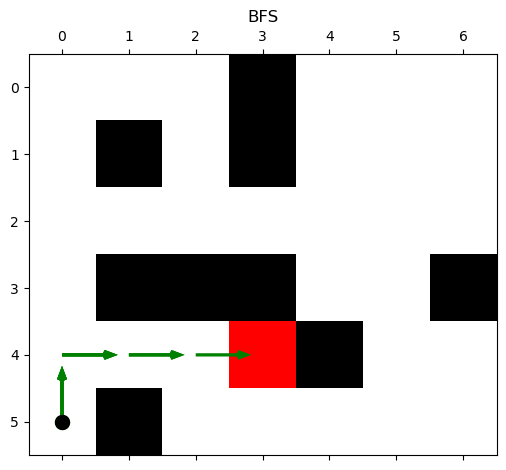

In [13]:
fig, ax = env.showGrid()
ax.plot(trajectory_bfs[0][0], trajectory_bfs[0][1], 'ok', markersize=10) #draw the spawn location of the agent
xs, ys = zip(*trajectory_bfs)
ax.set_title(f"BFS")
fig.tight_layout()
def update_quiver(i):
    # Switch the y and x variables to unpack the coordinates correctly if using the trajectory from Path
    x = np.array(xs)[:i]
    y = np.array(ys)[:i]
    ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1],
    scale_units='xy', angles='xy', scale=1.2, color='g', width=0.007, headwidth=3., headlength=4.)
anim = animation.FuncAnimation(fig, update_quiver, frames=len(trajectory_bfs)+1, interval=500, blit=False, repeat=True)
anim.save('plot_grid.gif', writer=animation.PillowWriter(fps=60))
plt.show()

Comparison of DFS and BFS
Depth First Search
1. DFS implements the deepest node to expand first.
2. The fringe used is a stack
3. As seen in the DFS grid, it finds a not so optimal path
4. The solutions is guaranteed but not the most optimal

Breadth First Search
1. BFS implements the shallowest one
2. The fringe used is a queue
3. As seen in the BFS grid, it finds the shortest path
4. It guarantees to find the shortest path, and mostly more optimal path as compares to DFS.

UCS Agent

In [14]:
env =  Environment()
s = env.reset()

In [15]:
# Define an agent
from myAgent import UCSAgent
agent_ucs = UCSAgent()
trajectory_ucs = []
s = env.reset()

In [16]:
"""
Trajectory through path from UCS: Uncomment to see the same path
"""
# isFound, path, selected_actions = agent_ucs.ucs_search(map, start, goal)
# trajectory_ucs.insert(0, start)
# trajectory_ucs[1:1] = path
# print(trajectory_ucs)
# print('Actions', selected_actions)


'\nTrajectory through path from UCS: Uncomment to see the same path\n'

In [17]:
"""
Trajectory following the actions from UCS
Path obtained from Step function is the same as the 'path' from UCS
"""
isFound, path, selected_actions = agent_ucs.ucs_search(map, start, goal)

for action in selected_actions:
    s, reward, terminal, agentX, agentY = env.step(action)
    trajectory_ucs.append((agentX, agentY))
    if terminal:
        break
trajectory_ucs = [(start[1],start[0])] + trajectory_ucs
print(trajectory_ucs)

Unform cost search - UCS
[(0, 5), (0, 4), (0, 3), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (4, 3), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (3, 4)]


/Users/shrutisingh/Desktop/PhD classes/Fall 23/Artificial Intelligence/Assignment/HW2_Shruti/gridworld_part2.py:121: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  self.ax.plot(self.AGENTS_X, self.AGENTS_Y, 'ok', markersize=10, color = 'green')


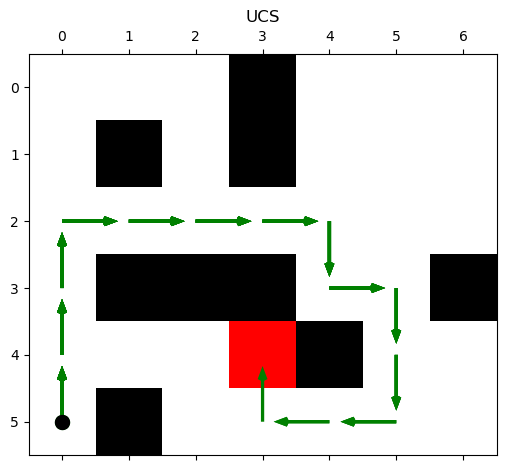

In [18]:
fig, ax = env.showGrid()
ax.plot(trajectory_ucs[0][0], trajectory_ucs[0][1], 'ok', markersize=10) #draw the spawn location of the agent
xs, ys = zip(*trajectory_ucs)
ax.set_title(f"UCS")
fig.tight_layout()
def update_quiver(i):
    # Switch the y and x variables to unpack the coordinates correctly if using the trajectory from Path
    x = np.array(xs)[:i]
    y = np.array(ys)[:i]
    ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1],
    scale_units='xy', angles='xy', scale=1.2, color='g', width=0.007, headwidth=3., headlength=4.)
anim = animation.FuncAnimation(fig, update_quiver, frames=len(trajectory_ucs)+1, interval=500, blit=False, repeat=True)
anim.save('plot_grid.gif', writer=animation.PillowWriter(fps=60))
plt.show()

AStar

In [19]:
env =  Environment()
s = env.reset()

In [20]:
# Define an agent
from myAgent import AStarAgent
agent_astar = AStarAgent()
trajectory_astar = []
s = env.reset()

In [21]:
"""
Trajectory through path from AStar: Uncomment to see the same path
"""
# isFound, path, visit_count, selected_actions = agent_astar.astar_search(map, start, goal)
# trajectory_astar.insert(0, start)
# trajectory_astar[1:1] = path
# print(trajectory_astar)
# print('Actions:', selected_actions)

'\nTrajectory through path from AStar: Uncomment to see the same path\n'

In [22]:
"""
Trajectory following the actions from Astart
Path obtained from Step function is the same as the 'path' from Astar
"""
isFound, path, costs_visited, selected_actions = agent_astar.astar_search(map, start, goal)

for action in selected_actions:
    s, reward, terminal, agentX, agentY = env.step(action)
    trajectory_astar.append((agentX, agentY))
    if terminal:
        break
trajectory_astar = [(start[1],start[0])] + trajectory_astar
print(trajectory_astar)

[(0, 5), (0, 4), (0, 3), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (4, 3), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (3, 4)]


/Users/shrutisingh/Desktop/PhD classes/Fall 23/Artificial Intelligence/Assignment/HW2_Shruti/gridworld_part2.py:121: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  self.ax.plot(self.AGENTS_X, self.AGENTS_Y, 'ok', markersize=10, color = 'green')


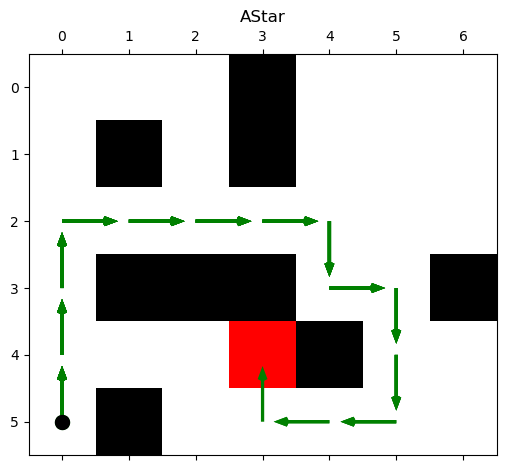

In [23]:
fig, ax = env.showGrid()
ax.plot(trajectory_astar[0][0], trajectory_astar[0][1], 'ok', markersize=10) #draw the spawn location of the agent
xs, ys = zip(*trajectory_astar)
ax.set_title(f"AStar")
fig.tight_layout()
def update_quiver(i):
    # Switch the y and x variables to unpack the coordinates correctly if using the trajectory from Path
    x = np.array(xs)[:i]
    y = np.array(ys)[:i]
    ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1],
    scale_units='xy', angles='xy', scale=1.2, color='g', width=0.007, headwidth=3., headlength=4.)
anim = animation.FuncAnimation(fig, update_quiver, frames=len(trajectory_astar)+1, interval=500, blit=False, repeat=True)
anim.save('plot_grid.gif', writer=animation.PillowWriter(fps=60))
plt.show()